# Spectral Template Analysis

This notebook:
1. Loads a trained checkpoint
2. Finds the best-fit redshift and amplitudes for a selection of galaxies
3. Plots observed spectra with template fits
4. Compares the recovered n(z) with the true redshift histogram

In [1]:
import sys, os, glob, json
sys.path.insert(0, '../py')

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from spectra_loader import SpectraDataset
from template_model import TemplateModel

print('JAX devices:', jax.devices())

JAX devices: [CudaDevice(id=0)]


## Configuration

In [7]:
# ---- Paths (adjust as needed) -----------------------------------------------
SPECTRA_DIR    = '../spectra/'
ZERR_CATALOG   = '../metadata/desi-galaxy-cat-zerr.fits'
CHECKPOINT_DIR = '../checkpoints/'

# Galaxy selection
N_GALAXIES     = 500    # number of galaxies to analyse
ZMIN           = 0.4
ZMAX           = 0.7
DESI_TARGET_MASK = None  # set to e.g. 1 to select a specific target class

# Plotting
N_PLOT = 8   # number of example spectra to plot


## Load galaxy data

In [8]:
ds = SpectraDataset(
    SPECTRA_DIR,
    zerr_catalog=ZERR_CATALOG,
    n_spectra=N_GALAXIES,
    zmin=ZMIN,
    zmax=ZMAX,
    desi_target_mask=DESI_TARGET_MASK,
)
print(f'{len(ds)} galaxies loaded')

# Load all into memory as JAX arrays
all_flux   = np.stack([ds[i]['flux'].numpy()  for i in range(len(ds))])
all_ivar   = np.stack([ds[i]['ivar'].numpy()  for i in range(len(ds))])
all_z      = np.array([ds[i]['z'].item()      for i in range(len(ds))])
all_zerr   = np.array([ds[i]['zerr'].item()   for i in range(len(ds))])

flux   = jnp.array(all_flux)
ivar   = jnp.array(all_ivar)
z_prior = jnp.array(all_z)
zerr    = jnp.array(all_zerr)

500 galaxies loaded


## Load checkpoint

In [105]:
# Find the latest checkpoint
ckpt_files = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, 'checkpoint_epoch*.npz')))
if not ckpt_files:
    raise FileNotFoundError(
        f'No checkpoints found in {CHECKPOINT_DIR}. '
        'Run scripts/train.py first.'
    )
ckpt_path = ckpt_files[-1]
print(f'Loading: {ckpt_path}')

# We need wave_obs before loading; read it from the first spectra file
import fitsio
first_file = sorted(glob.glob(os.path.join(SPECTRA_DIR, 'spec-*.fits')))[0]
with fitsio.FITS(first_file) as f:
    wave_obs = f['wave'].read().astype(np.float32)

model, params, epoch = TemplateModel.load_checkpoint(ckpt_path, wave_obs)
print(f'Loaded epoch {epoch}: Nt={model.Nt}, Nz={model.Nz}, '
      f'z=[{model.zmin}, {model.zmax}]')

Loading: ../checkpoints/checkpoint_epoch0114.npz
Loaded epoch 114: Nt=5, Nz=1000, z=[0.3, 0.8]


## Compute z posteriors and best-fit redshifts

In [106]:
# log_posterior shape: (N, Nz)
compute_posterior = jax.jit(model.compute_z_posterior)

# non-informative prior
z_prior_eval = jnp.full((len(ds),), (model.zmin + model.zmax) / 2.0)
zerr_eval    = jnp.full((len(ds),), 100.0)

log_post = compute_posterior(params, flux, ivar, z_prior_eval, zerr_eval)
log_post_np = np.array(log_post)

# Best-fit z per galaxy
best_z_idx = np.argmax(log_post_np, axis=1)               # (N,)
zgrid_np   = np.array(model.zgrid)
best_z     = zgrid_np[best_z_idx]                          # (N,)

dz = best_z - all_z
print(f'Delta-z (fit - catalog):  mean={dz.mean():.4f}  std={dz.std():.4f}')


Delta-z (fit - catalog):  mean=-0.1215  std=0.0694


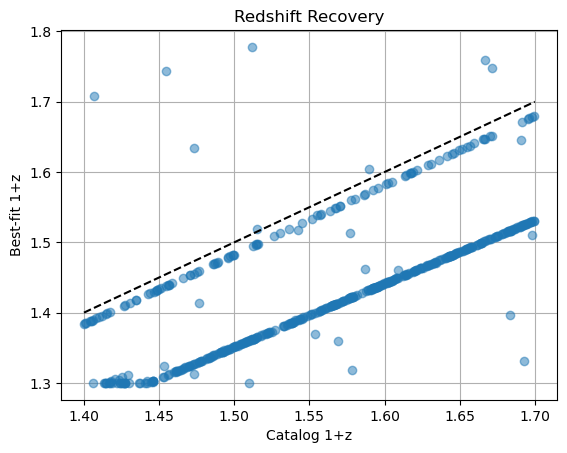

In [107]:
plt.plot(1+all_z, 1+best_z, 'o', alpha=0.5)
plt.plot([1+ZMIN, 1+ZMAX], [1+ZMIN, 1+ZMAX], 'k--')
plt.xlabel('Catalog 1+z')
plt.ylabel('Best-fit 1+z')
plt.title('Redshift Recovery')
plt.grid()
plt.show()

## Compute best-fit alpha and template reconstructions

In [99]:
predict_alpha = jax.jit(model.predict_alpha)
best_z_jax = jnp.array(best_z)
alpha = np.array(predict_alpha(params, flux, ivar, best_z_jax))   # (N, Nt)

# Reconstruct spectra: prediction[i] = sum_k alpha[i,k] * T_z[k]
T_np   = np.array(params['T'])      # (Nt, Nft)
t_wave = np.array(model.t_wave)     # (Nft,)

def reconstruct(alpha_i, z_i):
    """Interpolate templates and compute prediction for galaxy i."""
    rest_wave = wave_obs / (1.0 + z_i)
    T_z = np.array([np.interp(rest_wave, t_wave, T_np[k]) for k in range(model.Nt)])
    return (alpha_i[:, None] * T_z).sum(axis=0)   # (Nf,)

predictions = np.array([reconstruct(alpha[i], best_z[i]) for i in range(len(ds))])

## Plot spectra with template fits

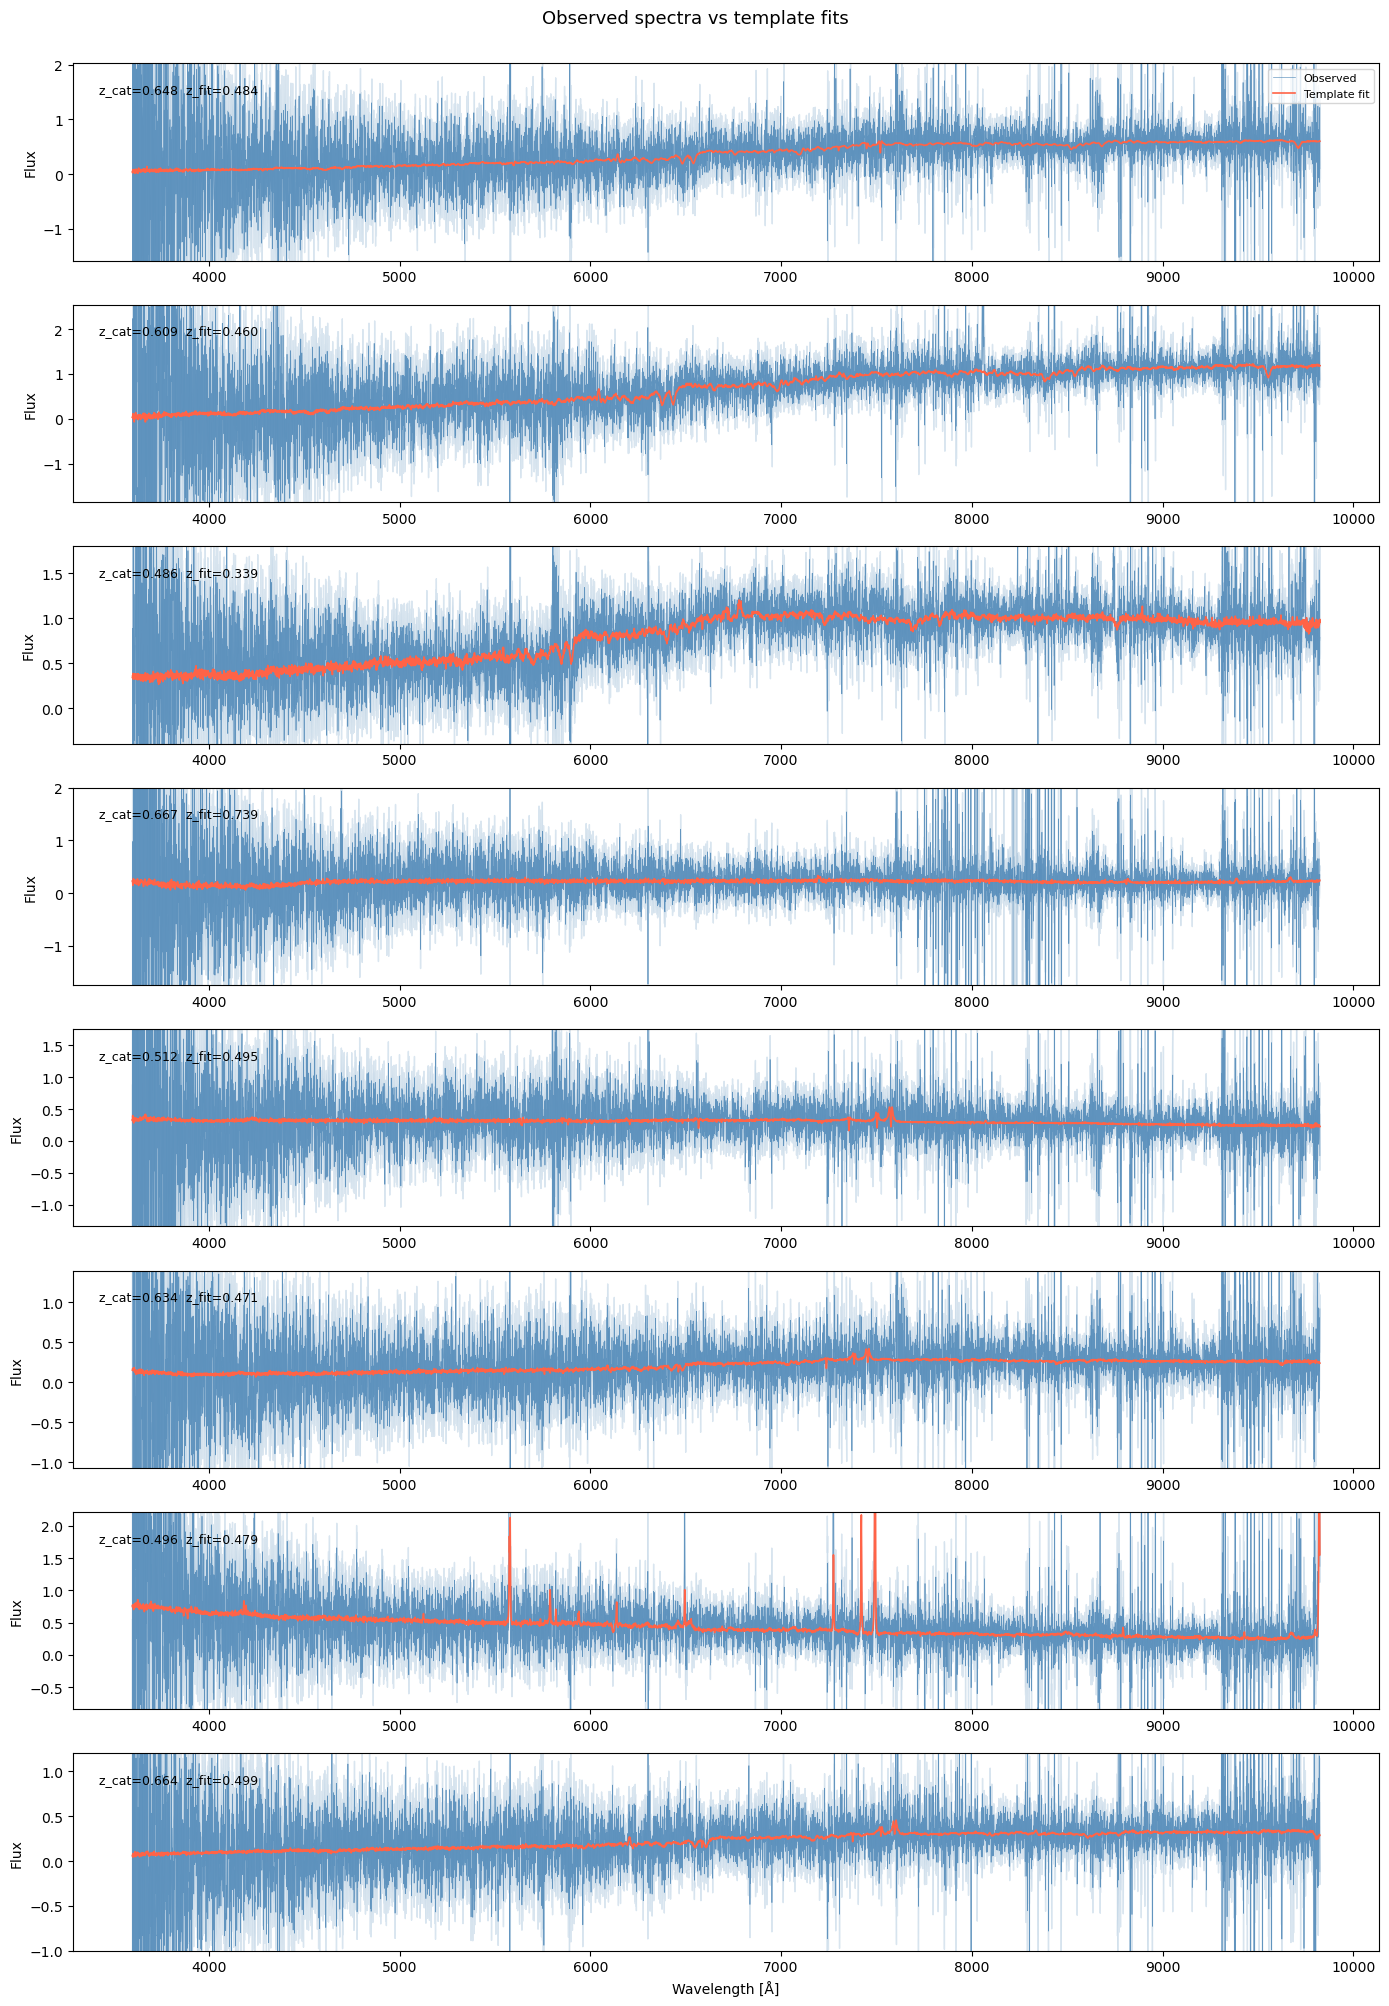

In [100]:
fig, axes = plt.subplots(N_PLOT, 1, figsize=(14, 2.5 * N_PLOT), sharex=False)

for i, ax in enumerate(axes):
    fl  = all_flux[i]
    iv  = all_ivar[i]
    pred = predictions[i]
    z_cat = all_z[i]
    z_fit = best_z[i]

    # 1-sigma error from ivar
    safe_iv = np.where(iv > 0, iv, np.nan)
    sigma   = 1.0 / np.sqrt(safe_iv)

    # Clip y-axis at 5th–99th percentile of valid flux
    valid = fl[iv > 0]
    if len(valid) > 10:
        ylo, yhi = np.percentile(valid, [2, 98])
        pad = 0.15 * (yhi - ylo)
    else:
        ylo, yhi, pad = fl.min(), fl.max(), 0.1

    ax.plot(wave_obs, fl, color='steelblue', lw=0.5, alpha=0.8, label='Observed')
    ax.fill_between(wave_obs, fl - sigma, fl + sigma,
                    color='steelblue', alpha=0.2)
    ax.plot(wave_obs, pred, color='tomato', lw=1.2, label='Template fit')
    ax.set_ylim(ylo - pad, yhi + pad)
    ax.set_ylabel('Flux')
    ax.text(0.02, 0.90,
            f'z_cat={z_cat:.3f}  z_fit={z_fit:.3f}',
            transform=ax.transAxes, fontsize=9, va='top')
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Wavelength [Å]')
fig.suptitle('Observed spectra vs template fits', fontsize=13, y=1.001)
fig.tight_layout()
plt.show()

## Plot z posterior for a single galaxy

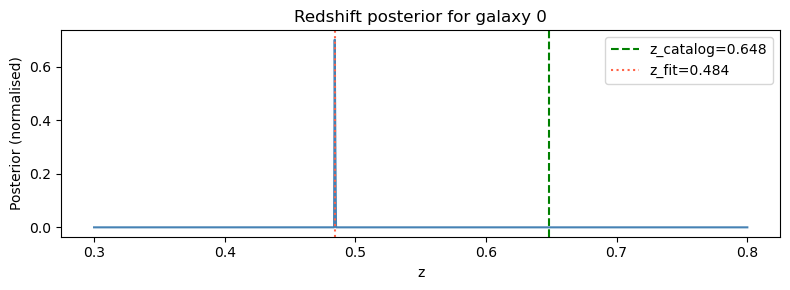

In [101]:
idx = 0   # change to inspect different galaxies
lp = log_post_np[idx]
# Normalise for display
lp_norm = lp - lp.max()
posterior = np.exp(lp_norm)
posterior /= posterior.sum()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(zgrid_np, posterior, color='steelblue')
ax.axvline(all_z[idx],  color='green',  lw=1.5, ls='--', label=f'z_catalog={all_z[idx]:.3f}')
ax.axvline(best_z[idx], color='tomato', lw=1.5, ls=':',  label=f'z_fit={best_z[idx]:.3f}')
ax.set_xlabel('z')
ax.set_ylabel('Posterior (normalised)')
ax.set_title(f'Redshift posterior for galaxy {idx}')
ax.legend()
plt.tight_layout()
plt.show()

## Recovered n(z) vs true redshift histogram

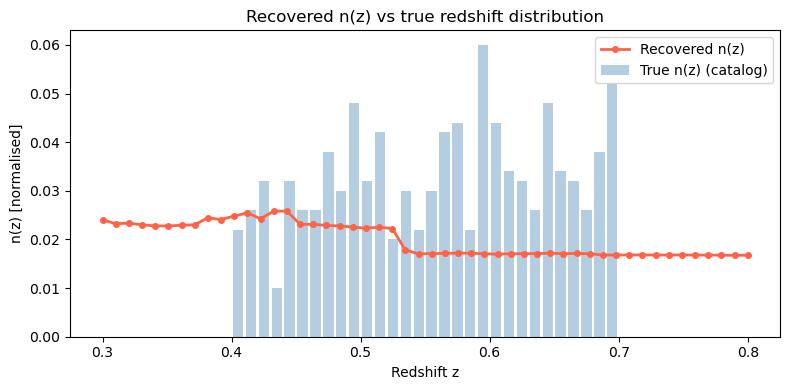

In [102]:
log_nz_raw = np.array(params['log_nz_raw'])
log_nz_norm = log_nz_raw - np.log(np.sum(np.exp(log_nz_raw - log_nz_raw.max()))) - log_nz_raw.max()
nz_recovered = np.exp(log_nz_norm)
nz_recovered /= nz_recovered.sum()   # ensure exact normalisation

z_nz_grid = np.array(model.z_nz_grid)

fig, ax = plt.subplots(figsize=(8, 4))

# True histogram
bins = np.linspace(model.zmin, model.zmax, model.Nnz + 1)
counts, edges = np.histogram(all_z, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])
true_nz = counts / counts.sum()
ax.bar(centers, true_nz,
       width=(edges[1] - edges[0]) * 0.8,
       alpha=0.4, color='steelblue', label='True n(z) (catalog)')

# Recovered n(z)
ax.plot(z_nz_grid, nz_recovered, color='tomato', lw=2, marker='o', ms=4,
        label='Recovered n(z)')

ax.set_xlabel('Redshift z')
ax.set_ylabel('n(z) [normalised]')
ax.set_title('Recovered n(z) vs true redshift distribution')
ax.legend()
plt.tight_layout()
plt.show()

## Template shapes

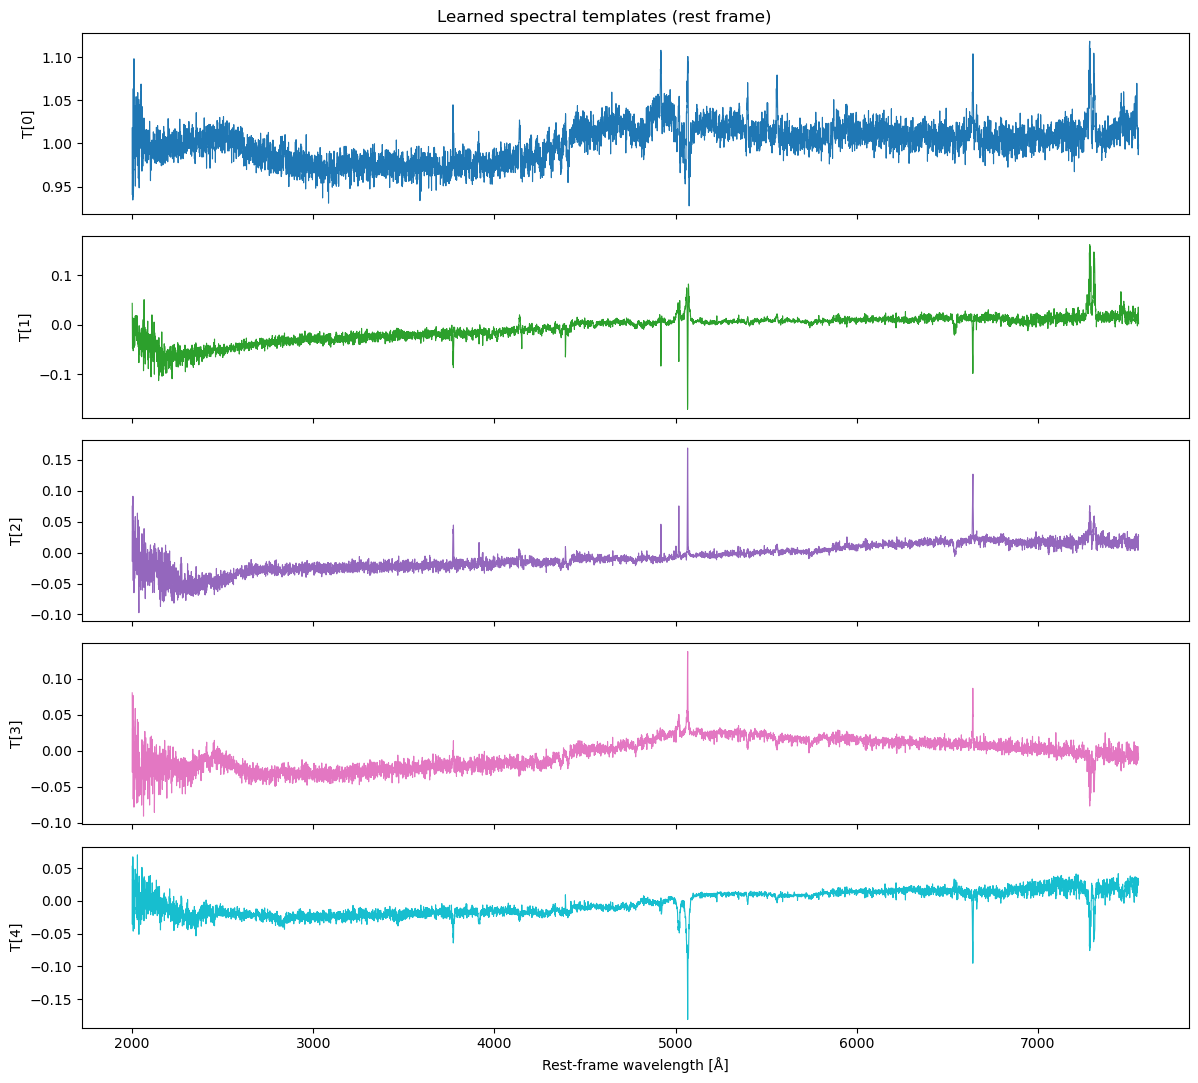

In [103]:
fig, axes = plt.subplots(model.Nt, 1, figsize=(12, 2.2 * model.Nt), sharex=True)
if model.Nt == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 0.9, model.Nt))
for k, ax in enumerate(axes):
    ax.plot(t_wave, T_np[k], color=colors[k], lw=0.8)
    ax.set_ylabel(f'T[{k}]')

axes[-1].set_xlabel('Rest-frame wavelength [Å]')
fig.suptitle('Learned spectral templates (rest frame)', fontsize=12)
plt.tight_layout()
plt.show()

## Template shifted to observed frame

Show each template evaluated at the median redshift of the sample, overlaid on the mean spectrum.

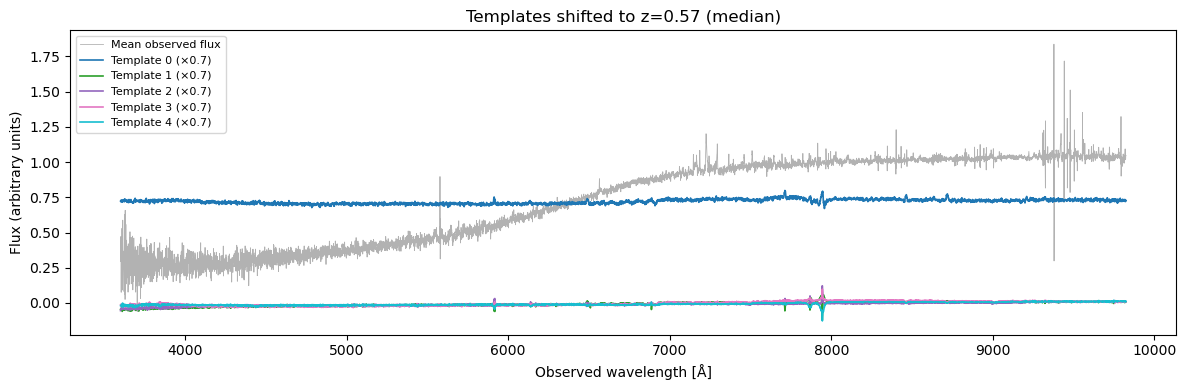

In [104]:
z_median = float(np.median(all_z))
mean_flux = all_flux.mean(axis=0)

# Interpolate each template to observed frame at z_median
rest_wave_med = wave_obs / (1.0 + z_median)
T_at_z = np.array([np.interp(rest_wave_med, t_wave, T_np[k]) for k in range(model.Nt)])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wave_obs, mean_flux, color='gray', lw=0.6, alpha=0.6, label='Mean observed flux')

# Scale templates to match mean flux level for display
scale = mean_flux[mean_flux > 0].mean() / (T_at_z[0][T_at_z[0] > 0].mean() + 1e-10)
for k in range(model.Nt):
    ax.plot(wave_obs, T_at_z[k] * scale, color=colors[k], lw=1.2,
            label=f'Template {k} (×{scale:.1f})')

ax.set_xlabel('Observed wavelength [Å]')
ax.set_ylabel('Flux (arbitrary units)')
ax.set_title(f'Templates shifted to z={z_median:.2f} (median)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()